## Computing Economic Index

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import json

### 1. Loading economic dataset

In [2]:
# Read the CSV file
csv_path = "economic_data.csv"
df1 = pd.read_csv(csv_path)

In [3]:
display(df1.head())

,Country Name,Country Code,Year,GDP per Capita,GDP,GNI,GNI per Capita,Foreign Investment,GINI Index,Unemployment Rate,Labor Force participation rate
0,Albania,ALB,2000,1126.683340,3.480355e+09,3.585007e+09,1100.0,1.430000e+08,NaN,19.023,60.435
1,Albania,ALB,2001,1281.659826,3.922101e+09,4.048094e+09,1280.0,2.073000e+08,NaN,18.570,59.888
2,Albania,ALB,2002,1425.124219,4.348068e+09,4.457186e+09,1370.0,1.350000e+08,31.7,17.891,59.610
3,Albania,ALB,2003,1846.120121,5.611496e+09,5.762066e+09,1650.0,1.780364e+08,NaN,16.985,58.557
4,Albania,ALB,2004,2373.581292,7.184686e+09,7.353975e+09,2100.0,3.412851e+08,NaN,16.306,57.496


In [4]:
# Here we find missing values especially in GINI index
print(df1.isnull().sum())

Country Name                        0
Country Code                        0
Year                                0
GDP per Capita                     32
GDP                                37
GNI                               113
GNI per Capita                    125
Foreign Investment                218
GINI Index                        814
Unemployment Rate                 171
Labor Force participation rate    171
dtype: int64


### 2. Select values and compute Economic Index

In [ ]:
# Select only relevant columns that we want to include in our index
columns = [
    "Foreign Investment",
    "GNI per Capita",
    "Unemployment Rate",
    "Labor Force participation rate",
]
df = df1[["Country Name", "Year"] + columns]

# Check for missing values
print("Missing values before filling:", df.isna().sum())

# Imputation with mean based on the country's previous data
df[columns] = df.groupby("Country Name")[columns].transform(
    lambda x: x.fillna(x.mean())
)

# Check again for any missing values
print("Missing values after country-level filling:", df.isna().sum())

# Normalize the data (Min-Max Scaling) to get a readable indecx
scaler = MinMaxScaler()
df[columns] = scaler.fit_transform(df[columns])


# Define weights for the Economic Index
weights = {
    "Foreign Investment": 0.1,
    "GNI per Capita": 0.5,
    "Unemployment Rate": -0.2,
    "Labor Force participation rate": 0.2,
}

# Compute Economic Index: The sum of all the weights
df["GNI Economic Index"] = sum(df[col] * weight for col, weight in weights.items())

# Sort by Economic Index (highest to lowest)
df_sorted = df.sort_values(by="GNI Economic Index", ascending=False)

Missing values before filling: Country Name                        0
Year                                0
Foreign Investment                218
GNI per Capita                    125
Unemployment Rate                 171
Labor Force participation rate    171
dtype: int64
Missing values after country-level filling: Country Name                        0
Year                                0
Foreign Investment                168
GNI per Capita                     48
Unemployment Rate                 168
Labor Force participation rate    168
dtype: int64


C:\Users\gebruikerr\AppData\Local\Temp\ipykernel_36404\1175099640.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columns] = df.groupby("Country Name")[columns].transform(lambda x: x.fillna(x.mean()))
C:\Users\gebruikerr\AppData\Local\Temp\ipykernel_36404\1175099640.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[columns] = scaler.fit_transform(df[columns])
C:\Users\gebruikerr\AppData\Local\Temp\ipykernel_36404\1175099640.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy 

In [ ]:
desktop_path = "economic_index_sorted.csv"
df_sorted.to_csv(desktop_path, index=False)
print(f"File saved to: {desktop_path}")

File saved to: C:\Users\gebruikerr\OneDrive\Desktop\economic_index_sorted.csv


In [7]:
# Sort the DataFrame by 'GNI econ indec' in descending order and show the top 5 rows
top_gni = df_sorted.sort_values(by="GNI Economic Index", ascending=False).head(5)
display(top_gni)

,Country Name,Year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,GNI Economic Index
1189,Qatar,2013,0.295509,0.793888,0.004836,0.976958,0.620919
1190,Qatar,2014,0.297313,0.758071,0.002687,0.985083,0.605246
1188,Qatar,2012,0.296695,0.762014,0.010210,0.976489,0.603933
1187,Qatar,2011,0.297215,0.687834,0.012359,0.979822,0.567131
1093,Norway,2013,0.295003,0.859854,0.089334,0.610157,0.563592


In [8]:
display(df_sorted)

,Country Name,Year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,GNI Economic Index
1189,Qatar,2013,0.295509,0.793888,0.004836,0.976958,0.620919
1190,Qatar,2014,0.297313,0.758071,0.002687,0.985083,0.605246
1188,Qatar,2012,0.296695,0.762014,0.010210,0.976489,0.603933
1187,Qatar,2011,0.297215,0.687834,0.012359,0.979822,0.567131
1093,Norway,2013,0.295003,0.859854,0.089334,0.610157,0.563592
...,...,...,...,...,...,...,...
1531,Turkmenistan,2019,NaN,0.051672,0.105938,0.282775,NaN
1532,Turkmenistan,2020,NaN,0.054054,0.118243,0.260201,NaN
1533,Turkmenistan,2021,NaN,0.057833,0.117114,0.264183,NaN
1534,Turkmenistan,2022,NaN,0.062598,0.107711,0.283748,NaN


In [9]:
# Check for missing values in each column
print(df_sorted.isna().sum())

# If you want to check if there are any missing values at all
print("Total missing values:", df.isna().sum().sum())

Country Name                        0
Year                                0
Foreign Investment                168
GNI per Capita                     48
Unemployment Rate                 168
Labor Force participation rate    168
GNI Economic Index                192
dtype: int64
Total missing values: 744


### 3. Visualize Economic Index

C:\Users\gebruikerr\AppData\Local\Temp\ipykernel_36404\898786118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country Name", y="GNI Economic Index", data=df_sorted, palette="viridis")


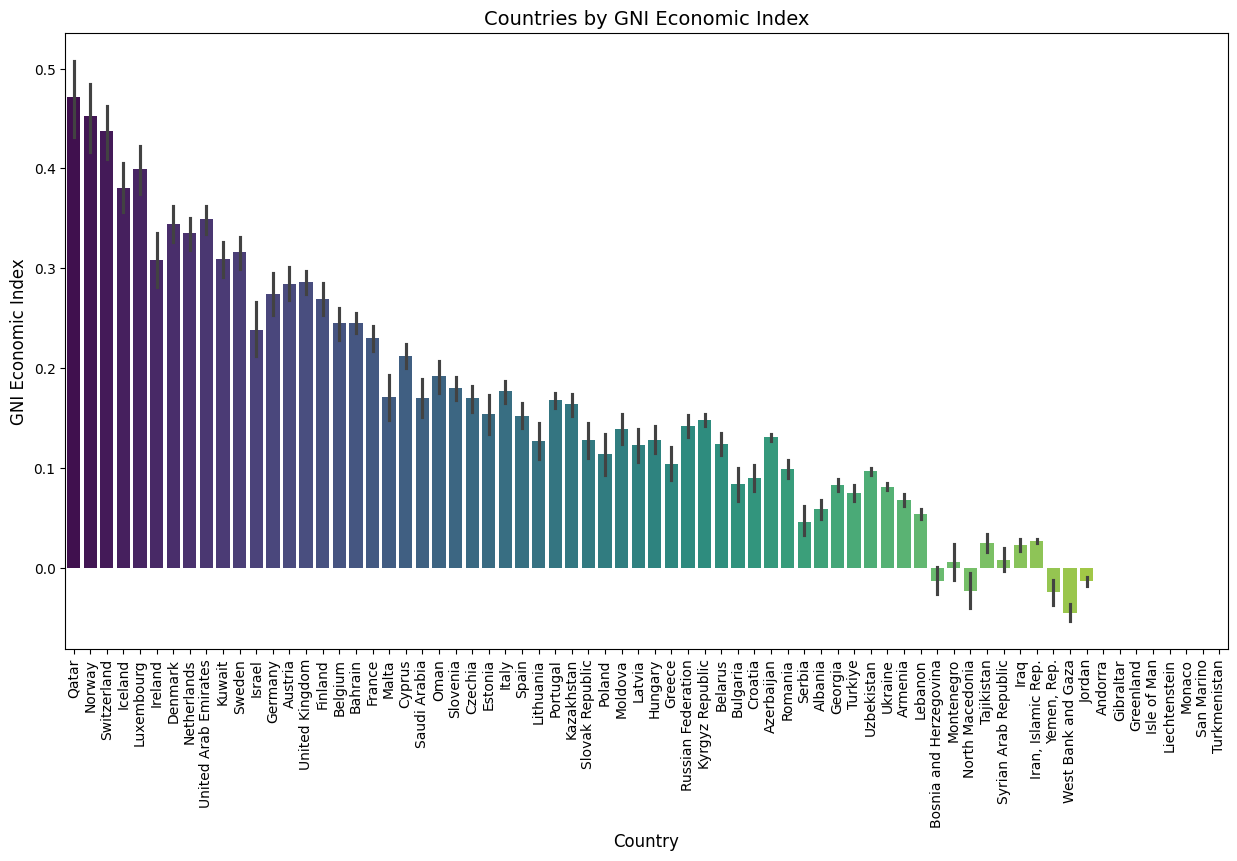

In [10]:
# Sort the DataFrame by Economic Index from highest to lowest
df_sorted = df_sorted.sort_values(by="GNI Economic Index", ascending=False)

# Plot all countries by Economic Index
plt.figure(figsize=(15, 8))
sns.barplot(x="Country Name", y="GNI Economic Index", data=df_sorted, palette="viridis")
plt.title("Countries by GNI Economic Index", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("GNI Economic Index", fontsize=12)
plt.xticks(rotation=90)
plt.show()

### 4. Data Checks

Checking and correcting data for any missing countries including Turkey, Palestine, Iran and the UK.

Turkey and Palestine

In [11]:
# Filter for Turkey and West Bank and Gaza
selected_df = df_sorted[
    df_sorted["Country Name"].isin(["Turkiye", "West Bank and Gaza"])
]
display(selected_df)

,Country Name,Year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,GNI Economic Index
1511,Turkiye,2023,0.306816,0.095046,0.249543,0.382745,0.104845
1501,Turkiye,2013,0.309321,0.101947,0.258275,0.338192,0.097889
1502,Turkiye,2014,0.309104,0.102440,0.263326,0.332282,0.095922
1503,Turkiye,2015,0.314787,0.097922,0.274154,0.346479,0.094905
1500,Turkiye,2012,0.309495,0.096279,0.244761,0.322302,0.094597
1510,Turkiye,2022,0.309420,0.086092,0.278479,0.378096,0.093911
1505,Turkiye,2017,0.307046,0.089789,0.290677,0.374079,0.092279
1506,Turkiye,2018,0.308254,0.086174,0.291671,0.380925,0.091763
1504,Turkiye,2016,0.309582,0.091843,0.290140,0.359090,0.090670
1499,Turkiye,2011,0.311832,0.090610,0.260317,0.320608,0.088547


In [ ]:
# Load all_data JSON into a DataFrame
all_data_df = pd.read_json("all_data.json")

# 'year' column name is consistent
selected_df_renamed = selected_df.rename(columns={"Year": "year"})

# Merge correct GNI Economic Index into all_data_df
merged_df = all_data_df.merge(
    selected_df_renamed[["Country Name", "year", "GNI Economic Index"]],
    on=["Country Name", "year"],
    how="left",
)

# Economic Index_y only for Turkiye and West Bank and Gaza
mask = merged_df["Country Name"].isin(["Turkiye", "West Bank and Gaza"])
merged_df.loc[mask, "Economic Index_y"] = merged_df.loc[mask, "GNI Economic Index"]

# Drop the helper column
merged_df.drop(columns=["GNI Economic Index"], inplace=True)

display(merged_df)
# merged_df now contains corrected Economic Index_y values

,Country Name,year,Foreign Investment,GDP per Capita,Unemployment Rate,Labor Force participation rate,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),Income group,imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index,Economic Index_y
0,qatar,2022,2.963881e-01,0.345357,0.000806,1.000000,0.008931,0.055823,0.002571,0.382979,0.382979,0.002623,0.352037,0.030656,High income,0.352037,0.030656,0.152325,0.152325,0.520737
1,qatar,2023,2.958604e-01,0.312189,0.000806,0.999550,0.009345,0.068468,0.002371,0.574468,0.574468,0.002769,0.630353,NaN,High income,0.630353,0.068537,NaN,0.241347,0.554932
2,luxembourg,2021,3.463463e-01,0.520874,0.146991,0.529915,0.025711,0.031610,0.015618,0.319149,0.319149,0.017734,0.710388,NaN,High income,0.710388,0.088587,NaN,0.190993,0.470416
3,qatar,2018,2.942187e-01,0.276485,0.000269,0.998703,0.007602,0.002526,0.001653,0.255319,0.255319,0.002178,0.127383,0.012695,High income,0.127383,0.012695,0.083084,0.083084,0.488905
4,qatar,2021,2.952666e-01,0.279262,0.001075,0.978165,0.008310,0.041304,0.002370,0.404255,0.404255,0.002479,0.446277,0.029791,High income,0.446277,0.029791,0.167380,0.167380,0.499364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
607,Turkiye,2021,1.289500e+10,9743.212778,11.969000,51.359000,0.962204,0.494445,0.873416,0.000000,0.000000,0.886211,0.565686,0.876145,None,0.565686,0.876145,0.582263,0.582263,0.077057
608,West Bank and Gaza,2022,3.108255e+08,3799.955270,24.420000,44.991000,0.026975,0.000000,0.014687,0.391304,0.391304,0.027054,0.763999,0.568145,None,0.763999,0.568145,0.272934,0.272934,-0.035728
609,Turkiye,2022,1.366600e+10,10674.504158,10.465000,53.055000,1.000000,0.744434,0.954099,0.000000,0.000000,0.947743,0.365578,1.000000,None,0.365578,1.000000,0.626482,0.626482,0.093911
610,West Bank and Gaza,2023,1.035354e+08,3372.349744,NaN,NaN,0.013039,0.003542,0.018304,0.304348,0.304348,0.031446,1.000000,NaN,None,1.000000,1.229347,NaN,0.363047,-0.039573


In [ ]:
merged_df.to_json("all_data.json", orient="records", indent=2)

Iran and UK

In [ ]:
# Filter for Iran and the UK
selected_df = df_sorted[
    df_sorted["Country Name"].isin(["Iran, Islamic Rep.", "United Kingdom"])
]
display(selected_df)

,Country Name,year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,GNI Economic Index
1592,United Kingdom,2008,0.539359,0.396123,0.150591,0.542076,0.330294
1591,United Kingdom,2007,0.497224,0.387990,0.140838,0.537536,0.323057
1606,United Kingdom,2022,0.339369,0.397273,0.097528,0.537536,0.320575
1600,United Kingdom,2016,0.607787,0.351598,0.128076,0.546093,0.320181
1590,United Kingdom,2006,0.491587,0.367124,0.142692,0.540292,0.312241
1589,United Kingdom,2005,0.538591,0.349544,0.127217,0.532654,0.309719
1607,United Kingdom,2023,0.210550,0.390536,0.104352,0.535356,0.302524
1603,United Kingdom,2019,0.315293,0.353898,0.094385,0.549985,0.299598
1605,United Kingdom,2021,0.301163,0.372546,0.126975,0.538292,0.298653
1601,United Kingdom,2017,0.416525,0.340918,0.116926,0.546093,0.297945


In [ ]:
# Path to JSON file
# This file will not be found in the repositiory as it was merged in all_data.json
json_file_path = "other_data.json"

# Open and load the JSON data
with open(json_file_path, "r") as file:
    data = json.load(file)

# Convert JSON data into a DataFrame
other_data_df = pd.DataFrame(data)

# Show the first few rows to confirm it loaded correctly
display(other_data_df.head())

,Country Name,year,Foreign Investment,GNI per Capita,Unemployment Rate,Labor Force participation rate,Economic Index_y,v4_prefixes_ris,v6_prefixes_ris,asns_ris,v4_prefixes_stats,v6_prefixes_stats,asns_stats,speed (mgps),bandwidth (kbit/s),imputed speed,imputed bandwidth,non_imputed_internet_index,imputed_internet_index
0,United Kingdom,2008,0.539359,0.396123,0.150591,0.542076,0.330294,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,United Kingdom,2007,0.497224,0.387990,0.140838,0.537536,0.323057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,United Kingdom,2022,0.339369,0.397273,0.097528,0.537536,0.320575,0.937317,0.702935,0.981622,0.003448,0.003448,0.948827,0.570386,NaN,0.570386,4.173214,NaN,1.040150
3,United Kingdom,2016,0.607787,0.351598,0.128076,0.546093,0.320181,0.584173,0.274699,0.804142,0.000000,0.000000,0.685466,NaN,0.892632,0.362125,0.892632,NaN,0.450405
4,United Kingdom,2006,0.491587,0.367124,0.142692,0.540292,0.312241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
